# 🐦 Comparative Analysis of Sentiment Models — SemEval 2017 Task 4A
**Course**: COMP6885001 – Natural Language Processing | Bina Nusantara University
**Authors**: Nikolas Tjahjadi · Nur Hady · Luis Alexandro Soetherio

---
## 💻 VS Code / Mac — Resume-Safe Version
Setiap cell **cek disk dulu** sebelum train. Kalau model/cache sudah ada → langsung load & skip.

**Setup (terminal, sekali aja):**
```bash
cd '/Users/luissoetherio/Documents/NLP_FInal Project'
python3 -m venv nlp_env
source nlp_env/bin/activate
pip install ipykernel
python -m ipykernel install --user --name=nlp_env --display-name "NLP Env (Python)"
```
Lalu di VSCode: **Select Kernel → NLP Env (Python)**

**Run order:** Cell 1 (install) → Cell 2 (paths) → Cell 3 (imports) → Cell 4 (data) → Cell 5 (preprocess) → Cell 6 (tfidf) → Cell 7 (subsets) → Cell 8 (utils) → Cell 9 (M1) → Cell 10 (M2) → Cell 11 (M3) → Cell 12 (M4 OOF) → Cell 13 (M4 meta) → Cell 14 (M4 full retrain) → Cell 15 (M5 prep) → Cell 16 (M5 train) → Cell 17 (M5 eval) → Cell 18 (ablation) → Cell 19 (mcnemar) → Cell 20 (summary) → Cell 21 (save) → Cell 22 (viz) → Cell 23 (checklist)

| Model | Feature | Classifier(s) | Role |
|-------|---------|--------------|------|
| M1 | TF-IDF (lexical) | LR, LinearSVM, XGBoost | Lexical-only baseline |
| M2 | Categorical (17-dim) | RF, XGBoost, LR | Categorical-only baseline |
| M3 | TF-IDF + Categorical (concat) | XGBoost | Static hybrid baseline |
| M4 | TF-IDF + Categorical (stacking) | Meta-LR / LightGBM | **Novel stacking ensemble** |
| M5 | Contextual embeddings | Fine-tuned BERTweet | Transformer SOTA reference |

---
# 📦 CELL 1 — Install Dependencies
> Jalanin sekali. Aman dirun ulang (idempotent).

In [2]:
import subprocess, sys

packages = [
    'numpy', 'pandas', 'scipy',
    'scikit-learn', 'xgboost', 'lightgbm',
    'vaderSentiment', 'emoji',
    'spacy', 'nltk',
    'torch', 'transformers', 'datasets', 'accelerate',
    'statsmodels',
    'matplotlib', 'seaborn',
]
print('Installing packages...')
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q'] + packages)
subprocess.check_call([sys.executable, '-m', 'spacy', 'download', 'en_core_web_sm', '-q'])

import nltk
for pkg in ['punkt', 'averaged_perceptron_tagger', 'wordnet', 'stopwords']:
    nltk.download(pkg, quiet=True)

print('✅ All packages installed.')

Installing packages...



[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
✅ All packages installed.


---
# ⚙️ CELL 2 — Paths & Config

In [3]:
import os

DATASET_DIR    = '/Users/luissoetherio/Documents/NLP_FInal Project/dataset'
MODEL_SAVE_DIR = '/Users/luissoetherio/Documents/NLP_FInal Project/saved_models'
RESULTS_DIR    = '/Users/luissoetherio/Documents/NLP_FInal Project/results'

os.makedirs(MODEL_SAVE_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR,    exist_ok=True)
os.makedirs(os.path.join(RESULTS_DIR, 'figures'), exist_ok=True)

TRAIN_FILES = [
    os.path.join(DATASET_DIR, 'train', 'twitter-2016train-A.txt'),
    os.path.join(DATASET_DIR, 'train', 'twitter-2016dev-A.txt'),
    os.path.join(DATASET_DIR, 'train', 'twitter-2016devtest-A.txt'),
    os.path.join(DATASET_DIR, 'train', 'twitter-2016test-A.txt'),
    os.path.join(DATASET_DIR, 'train', 'twitter-2015train-A.txt'),
    os.path.join(DATASET_DIR, 'train', 'twitter-2015test-A.txt'),
    os.path.join(DATASET_DIR, 'train', 'twitter-2014test-A.txt'),
    os.path.join(DATASET_DIR, 'train', 'twitter-2014sarcasm-A.txt'),
    os.path.join(DATASET_DIR, 'train', 'twitter-2013train-A.txt'),
    os.path.join(DATASET_DIR, 'train', 'twitter-2013dev-A.txt'),
    os.path.join(DATASET_DIR, 'train', 'twitter-2013test-A.txt'),
]
TEST_FILE = os.path.join(DATASET_DIR, 'test', 'SemEval2017-task4-test.subtask-A.english.txt')

for f in TRAIN_FILES + [TEST_FILE]:
    assert os.path.exists(f), f'Missing: {f}'

print(f'✅ Paths configured.')
print(f'   Dataset  → {DATASET_DIR}')
print(f'   Models   → {MODEL_SAVE_DIR}')
print(f'   Results  → {RESULTS_DIR}')

✅ Paths configured.
   Dataset  → /Users/luissoetherio/Documents/NLP_FInal Project/dataset
   Models   → /Users/luissoetherio/Documents/NLP_FInal Project/saved_models
   Results  → /Users/luissoetherio/Documents/NLP_FInal Project/results


---
# 📚 CELL 3 — Imports & Global Config

In [4]:
import re, time, json, pickle, warnings, copy
from collections import Counter
from itertools import product
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import scipy.sparse as sp
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import StratifiedKFold, GridSearchCV, train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from statsmodels.stats.contingency_tables import mcnemar

import spacy
from nltk.tokenize import TweetTokenizer
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import emoji

import torch
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, EarlyStoppingCallback,
    get_linear_schedule_with_warmup
)
from torch.utils.data import Dataset as TorchDataset
from datasets import Dataset

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

# ── Seeds ─────────────────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── Device: CUDA → MPS (Apple Silicon) → CPU ─────────────────────────────────
if torch.cuda.is_available():
    DEVICE = 'cuda'
elif torch.backends.mps.is_available():
    DEVICE = 'mps'
    torch.mps.manual_seed(SEED)
else:
    DEVICE = 'cpu'

nlp             = spacy.load('en_core_web_sm', disable=['ner', 'parser'])
vader           = SentimentIntensityAnalyzer()
tweet_tokenizer = TweetTokenizer(preserve_case=False, reduce_len=True, strip_handles=False)

LABEL_MAP     = {'negative': 0, 'neutral': 1, 'positive': 2}
LABEL_MAP_INV = {v: k for k, v in LABEL_MAP.items()}
LABEL_NAMES   = ['negative', 'neutral', 'positive']
CV5           = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# ── Resume helpers ────────────────────────────────────────────────────────────
def _pkl_path(name): return os.path.join(MODEL_SAVE_DIR, f'{name}.pkl')
def _npy_path(name): return os.path.join(MODEL_SAVE_DIR, f'{name}.npy')
def _pkl_exists(name): return os.path.exists(_pkl_path(name))
def _npy_exists(name): return os.path.exists(_npy_path(name))

def save_pkl(obj, name):
    with open(_pkl_path(name), 'wb') as f: pickle.dump(obj, f)
    print(f'  💾 {name}.pkl')

def load_pkl(name):
    with open(_pkl_path(name), 'rb') as f: return pickle.load(f)

def save_npy(arr, name):
    np.save(_npy_path(name), arr)
    print(f'  💾 {name}.npy')

def load_npy(name):
    return np.load(_npy_path(name))

print(f'✅ Imports done. Device: {DEVICE}')
print(f'   MPS: {torch.backends.mps.is_available()} | CUDA: {torch.cuda.is_available()}')

✅ Imports done. Device: mps
   MPS: True | CUDA: False


---
# 📂 CELL 4 — Data Loading

In [5]:
def load_semeval_file(path):
    rows = []
    with open(path, encoding='utf-8', errors='replace') as f:
        for line in f:
            parts = line.strip().split('\t')
            if len(parts) < 3: continue
            tid, label, text = parts[0], parts[1].lower().strip(), ' '.join(parts[2:])
            if label in LABEL_MAP:
                rows.append({'tweet_id': tid, 'label': label, 'text': text})
    return pd.DataFrame(rows)

df_train = pd.concat([load_semeval_file(f) for f in TRAIN_FILES], ignore_index=True)
df_train = df_train.drop_duplicates(subset='tweet_id').reset_index(drop=True)
df_test  = load_semeval_file(TEST_FILE)
df_train['y'] = df_train['label'].map(LABEL_MAP)
df_test['y']  = df_test['label'].map(LABEL_MAP)

print('=== Dataset Summary ===')
print(f'Train : {len(df_train):,} | Test: {len(df_test):,}')
print(df_train['label'].value_counts().to_string())

=== Dataset Summary ===
Train : 49,570 | Test: 12,284
label
neutral     22196
positive    19645
negative     7729


---
# 🛠️ CELL 5 — Preprocessing Pipeline
> **Resume**: load dari cache kalau ada. Skip ~10 menit preprocessing.

In [6]:
SLANG_DICT = {
    'luv':'love','idk':"i don't know",'tbh':'to be honest','imo':'in my opinion',
    'omg':'oh my god','lol':'laugh out loud','lmao':'laughing my ass off',
    'smh':'shaking my head','ngl':"not gonna lie",'irl':'in real life',
    'brb':'be right back','btw':'by the way','fyi':'for your information',
    'thx':'thanks','thnx':'thanks','ty':'thank you','ur':'your','u':'you',
    'r':'are','gr8':'great','b4':'before','2day':'today','2nite':'tonight',
    'pls':'please','plz':'please','gonna':'going to','wanna':'want to',
    'gotta':'got to','kinda':'kind of','sorta':'sort of','cuz':'because',
    'cos':'because','w/':'with','w/o':'without','ugh':'ugh','meh':'meh',
    'yay':'yay','yep':'yes','nope':'no','dope':'great','lit':'great',
    'sucks':'is bad','sux':'is bad','fav':'favorite','fave':'favorite',
    'prolly':'probably','def':'definitely','obv':'obviously','tho':'though',
    'tbt':'throwback thursday','smth':'something','rn':'right now'
}
NEGATION_MARKERS = {
    'not','no','never','neither','nobody','nothing','nowhere','nor',
    "n't",'cannot','cant','dont',"don't",'didnt',"didn't",'isnt',
    "isn't",'wasnt',"wasn't",'arent',"aren't",'wouldnt',"wouldn't",
    'shouldnt',"shouldn't",'couldnt',"couldn't",'without','hardly',
    'scarcely','barely'
}

def _normalize_elongation(text):
    count = len(re.findall(r'(.)\1{2,}', text))
    return re.sub(r'(.)\1{2,}', r'\1\1', text), count

def _extract_emoji_sentiment(text):
    pos_c = neg_c = 0
    for ch in text:
        if ch in emoji.EMOJI_DATA:
            desc  = emoji.demojize(ch).strip(':').replace('_', ' ')
            score = vader.polarity_scores(desc)['compound']
            if score > 0.05:    pos_c += 1
            elif score < -0.05: neg_c += 1
    return pos_c, neg_c

def preprocess_tweet(text, apply_layer2=True):
    raw_text = text
    text = text.lower()
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    text = re.sub(r'@\w+', ' ', text)
    text = re.sub(r'#(\w+)', r'\1', text)
    tokens = tweet_tokenizer.tokenize(text)
    if not apply_layer2:
        return ' '.join(tokens), {}
    emoji_pos, emoji_neg = _extract_emoji_sentiment(raw_text)
    excl_count    = raw_text.count('!')
    quest_count   = raw_text.count('?')
    uppercase_ratio = sum(1 for c in raw_text if c.isupper()) / max(len(raw_text), 1)
    repeated_punct  = len(re.findall(r'[!?]{2,}', raw_text))
    tokens = [SLANG_DICT.get(t, t) for t in tokens]
    text_joined, elong_count = _normalize_elongation(' '.join(tokens))
    tokens = text_joined.split()
    vader_scores = vader.polarity_scores(' '.join(tokens))
    negation_flag = 0
    prefixed_tokens = []
    negate_next = False
    for tok in tokens:
        clean_tok = tok.strip("'.,:;")
        if clean_tok in NEGATION_MARKERS:
            negation_flag = 1; negate_next = True; prefixed_tokens.append(tok)
        elif negate_next and re.match(r'[a-z]', clean_tok):
            prefixed_tokens.append('not_' + tok); negate_next = False
        else:
            if re.search(r'[.!?,;:]', tok): negate_next = False
            prefixed_tokens.append(tok)
    doc = nlp(' '.join(prefixed_tokens))
    lemmatized = [
        (tok.text if tok.text.startswith('not_') else tok.lemma_)
        for tok in doc if not tok.is_punct and not tok.is_space
    ]
    pos_counts = Counter(tok.pos_ for tok in doc)
    total = max(len(doc), 1)
    cat_features = {
        'vader_compound': vader_scores['compound'], 'vader_pos': vader_scores['pos'],
        'vader_neg': vader_scores['neg'],           'vader_neu': vader_scores['neu'],
        'emoji_pos_count': emoji_pos,               'emoji_neg_count': emoji_neg,
        'noun_ratio': pos_counts.get('NOUN',0)/total, 'verb_ratio': pos_counts.get('VERB',0)/total,
        'adj_ratio':  pos_counts.get('ADJ',0)/total,  'adv_ratio':  pos_counts.get('ADV',0)/total,
        'exclamation_count': excl_count,  'question_count': quest_count,
        'negation_flag': negation_flag,   'elongation_count': elong_count,
        'token_count': len(lemmatized),   'uppercase_char_ratio': uppercase_ratio,
        'repeated_punct_count': repeated_punct,
    }
    return ' '.join(lemmatized), cat_features

def preprocess_dataframe(df, label='Processing'):
    texts_clean, cat_list = [], []
    for i, row in enumerate(df.itertuples(), 1):
        txt, cats = preprocess_tweet(row.text, apply_layer2=True)
        texts_clean.append(txt); cat_list.append(cats)
        if i % 2000 == 0: print(f'  {label}: {i}/{len(df)}')
    return texts_clean, pd.DataFrame(cat_list)

print('✅ Preprocessing functions defined.')

✅ Preprocessing functions defined.


In [7]:
# ── Resume: load preprocessing cache kalau ada ───────────────────────────────
PREP_CACHE    = os.path.join(MODEL_SAVE_DIR, 'preprocessed_data.npz')
TRAIN_TXT_CSV = os.path.join(MODEL_SAVE_DIR, 'train_texts.csv')
TEST_TXT_CSV  = os.path.join(MODEL_SAVE_DIR, 'test_texts.csv')
TRAIN_CAT_CSV = os.path.join(MODEL_SAVE_DIR, 'train_cats.csv')
TEST_CAT_CSV  = os.path.join(MODEL_SAVE_DIR, 'test_cats.csv')

if all(os.path.exists(p) for p in [PREP_CACHE, TRAIN_TXT_CSV, TEST_TXT_CSV, TRAIN_CAT_CSV, TEST_CAT_CSV]):
    print('⏩ Preprocessing cache found — loading dari disk...')
    data        = np.load(PREP_CACHE)
    y_train     = data['y_train'];  y_test  = data['y_test']
    X_cat_train = data['X_cat_train']; X_cat_test = data['X_cat_test']
    train_texts = pd.read_csv(TRAIN_TXT_CSV).iloc[:, 0].tolist()
    test_texts  = pd.read_csv(TEST_TXT_CSV).iloc[:, 0].tolist()
    train_cats  = pd.read_csv(TRAIN_CAT_CSV)
    test_cats   = pd.read_csv(TEST_CAT_CSV)
    print(f'  Train: {len(train_texts)} | Test: {len(test_texts)}')
else:
    print('▶ Cache tidak ditemukan — running preprocessing...')
    t0 = time.time()
    train_texts, train_cats = preprocess_dataframe(df_train, 'Train')
    print(f'  Train done: {(time.time()-t0)/60:.1f} min')
    t0 = time.time()
    test_texts,  test_cats  = preprocess_dataframe(df_test,  'Test')
    print(f'  Test done : {(time.time()-t0)/60:.1f} min')

    y_train     = df_train['y'].values;  y_test  = df_test['y'].values
    X_cat_train = train_cats.values.astype(np.float32)
    X_cat_test  = test_cats.values.astype(np.float32)

    np.savez_compressed(PREP_CACHE, y_train=y_train, y_test=y_test,
                        X_cat_train=X_cat_train, X_cat_test=X_cat_test)
    pd.Series(train_texts).to_csv(TRAIN_TXT_CSV, index=False, header=['text'])
    pd.Series(test_texts).to_csv(TEST_TXT_CSV,   index=False, header=['text'])
    train_cats.to_csv(TRAIN_CAT_CSV, index=False)
    test_cats.to_csv(TEST_CAT_CSV,   index=False)
    df_train[['text','y']].to_csv(os.path.join(MODEL_SAVE_DIR,'train_raw.csv'), index=False)
    df_test[['text','y']].to_csv(os.path.join(MODEL_SAVE_DIR,'test_raw.csv'),   index=False)
    print(f'✅ Cache disimpan ke {MODEL_SAVE_DIR}')

print(f'X_cat: train={X_cat_train.shape} | test={X_cat_test.shape}')

⏩ Preprocessing cache found — loading dari disk...
  Train: 49570 | Test: 12284
X_cat: train=(49570, 17) | test=(12284, 17)


---
# 📐 CELL 6 — TF-IDF Vectorization
> **Resume**: load vectorizer dari disk kalau ada.

In [8]:
TFIDF_PKL = os.path.join(MODEL_SAVE_DIR, 'tfidf_vectorizer.pkl')

if os.path.exists(TFIDF_PKL):
    print('⏩ TF-IDF vectorizer found — loading...')
    with open(TFIDF_PKL, 'rb') as f: tfidf = pickle.load(f)
    X_lex_train = tfidf.transform(train_texts)
    X_lex_test  = tfidf.transform(test_texts)
else:
    print('▶ Fitting TF-IDF...')
    tfidf = TfidfVectorizer(ngram_range=(1,3), max_features=50_000, min_df=2, sublinear_tf=True)
    X_lex_train = tfidf.fit_transform(train_texts)
    X_lex_test  = tfidf.transform(test_texts)
    with open(TFIDF_PKL, 'wb') as f: pickle.dump(tfidf, f)
    print('  💾 tfidf_vectorizer.pkl')

X_hybrid_train = sp.hstack([X_lex_train, sp.csr_matrix(X_cat_train)])
X_hybrid_test  = sp.hstack([X_lex_test,  sp.csr_matrix(X_cat_test)])
print(f'✅ TF-IDF : train={X_lex_train.shape} | test={X_lex_test.shape}')
print(f'   Hybrid : train={X_hybrid_train.shape} | test={X_hybrid_test.shape}')

⏩ TF-IDF vectorizer found — loading...
✅ TF-IDF : train=(49570, 50000) | test=(12284, 50000)
   Hybrid : train=(49570, 50017) | test=(12284, 50017)


---
# 🧪 CELL 7 — Test Subset Partitions

In [9]:
raw = df_test['text'].values
has_emoji    = np.array([bool(emoji.emoji_count(t)) for t in raw])
neg_re       = re.compile(
    r"\b(not|no|never|neither|nobody|nothing|nowhere|nor|n't|cannot|can't|"
    r"don't|didn't|isn't|wasn't|aren't|wouldn't|shouldn't|couldn't|"
    r"without|hardly|scarcely|barely)\b", re.IGNORECASE)
has_negation = np.array([bool(neg_re.search(t)) for t in raw])
tok_counts   = np.array([len(t.split()) for t in test_texts])
is_short     = tok_counts < 8
slang_set    = set(SLANG_DICT.keys())
elong_re     = re.compile(r'(.)\1{2,}')
has_noise    = np.array([
    any(tok in slang_set for tok in t.lower().split()) or bool(elong_re.search(t))
    for t in raw
])
SUBSETS = {
    'emoji_present': has_emoji,    'emoji_absent':    ~has_emoji,
    'negation_present': has_negation, 'negation_absent': ~has_negation,
    'short_tweet': is_short,       'long_tweet':      ~is_short,
    'noisy': has_noise,            'clean':           ~has_noise,
}
print('✅ Sub-condition masks:')
for k,v in SUBSETS.items(): print(f'   {k:25s}: {v.sum():4d}')

✅ Sub-condition masks:
   emoji_present            :  809
   emoji_absent             : 11475
   negation_present         : 2041
   negation_absent          : 10243
   short_tweet              : 1422
   long_tweet               : 10862
   noisy                    : 1941
   clean                    : 10343


---
# 📊 CELL 8 — Utility Functions & ALL_RESULTS Init
> **Resume**: `ALL_RESULTS` di-init ulang tiap session, tapi model tetap load dari disk.

In [10]:
ALL_RESULTS = {}
TIMING      = {}

def evaluate(name, y_true, y_pred, timing=None):
    macro_f1 = f1_score(y_true, y_pred, average='macro')
    acc      = accuracy_score(y_true, y_pred)
    report   = classification_report(y_true, y_pred, target_names=LABEL_NAMES, output_dict=True)
    ALL_RESULTS[name] = {'macro_f1': macro_f1, 'accuracy': acc,
                         'report': report, 'preds': y_pred, 'timing': timing}
    if timing: TIMING[name] = timing
    t_str = f' | Time={timing:.1f}s' if timing else ''
    print(f'\n[{name}] Macro-F1={macro_f1:.4f} | Acc={acc:.4f}{t_str}')
    print(classification_report(y_true, y_pred, target_names=LABEL_NAMES))

def evaluate_subsets(name, y_true, y_pred):
    sub = {}
    print(f'  Sub-conditions [{name}]:')
    for cond, mask in SUBSETS.items():
        if mask.sum() < 20: continue
        f1 = f1_score(y_true[mask], y_pred[mask], average='macro')
        sub[cond] = f1
        print(f'    {cond:25s}: {f1:.4f}  (n={mask.sum()})')
    ALL_RESULTS[name]['subset_f1'] = sub

def mcnemar_test(preds_a, preds_b, y_true, name_a, name_b):
    a_c = (preds_a == y_true); b_c = (preds_b == y_true)
    b01 = np.sum(a_c & ~b_c); b10 = np.sum(~a_c & b_c)
    tbl = [[np.sum(a_c & b_c), b01],[b10, np.sum(~a_c & ~b_c)]]
    res = mcnemar(tbl, exact=True, correction=False)
    print(f'  McNemar ({name_a} vs {name_b}): b01={b01}, b10={b10}, p={res.pvalue:.4f}')
    return res.pvalue

print('✅ Utility functions defined.')

✅ Utility functions defined.


---
# 🔵 CELL 9 — M1: Lexical-Only (LR, LinearSVM, XGBoost)
> **Resume**: cek `M1_LR.pkl`, `M1_SVM.pkl`, `M1_XGB.pkl`. Skip kalau ada.

In [11]:
m1_configs = [
    ('M1_LR',
     LogisticRegression(max_iter=1000, solver='lbfgs', random_state=SEED),
     {'C': [0.01, 0.1, 1, 10]},
     X_lex_train, X_lex_test),
    ('M1_SVM',
     CalibratedClassifierCV(LinearSVC(max_iter=5000, random_state=SEED)),
     {'estimator__C': [0.1, 1, 10]},
     X_lex_train, X_lex_test),
    ('M1_XGB',
     XGBClassifier(use_label_encoder=False, eval_metric='mlogloss',
                   random_state=SEED, n_jobs=-1, tree_method='hist'),
     {'learning_rate': [0.01, 0.1], 'max_depth': [4, 6, 8], 'n_estimators': [100, 200]},
     X_lex_train, X_lex_test),
]

M1_BEST = {}
print('=== M1: Lexical-Only ===')
for name, estimator, param_grid, X_tr, X_te in m1_configs:
    if _pkl_exists(name):
        print(f'\n⏩ {name} — loading from disk...')
        M1_BEST[name] = load_pkl(name)
        y_pred = M1_BEST[name].predict(X_te)
    else:
        print(f'\n▶ Training {name}...')
        t0 = time.time()
        gs = GridSearchCV(estimator, param_grid, cv=CV5,
                          scoring='f1_macro', n_jobs=-1, verbose=1, refit=True)
        gs.fit(X_tr, y_train)
        elapsed = time.time() - t0
        y_pred  = gs.best_estimator_.predict(X_te)
        M1_BEST[name] = gs.best_estimator_
        save_pkl(gs.best_estimator_, name)
        ALL_RESULTS[name] = {'timing': elapsed}
        print(f'  Best params: {gs.best_params_} | CV F1: {gs.best_score_:.4f}')
    evaluate(name, y_test, y_pred)
    evaluate_subsets(name, y_test, y_pred)

best_m1_name = max(M1_BEST, key=lambda k: ALL_RESULTS[k]['macro_f1'])
print(f'\n✅ Best M1: {best_m1_name} (F1={ALL_RESULTS[best_m1_name]["macro_f1"]:.4f})')

=== M1: Lexical-Only ===

⏩ M1_LR — loading from disk...

[M1_LR] Macro-F1=0.5784 | Acc=0.5882
              precision    recall  f1-score   support

    negative       0.63      0.51      0.57      3972
     neutral       0.62      0.62      0.62      5937
    positive       0.49      0.63      0.55      2375

    accuracy                           0.59     12284
   macro avg       0.58      0.59      0.58     12284
weighted avg       0.60      0.59      0.59     12284

  Sub-conditions [M1_LR]:
    emoji_present            : 0.5873  (n=809)
    emoji_absent             : 0.5733  (n=11475)
    negation_present         : 0.5255  (n=2041)
    negation_absent          : 0.5784  (n=10243)
    short_tweet              : 0.5860  (n=1422)
    long_tweet               : 0.5748  (n=10862)
    noisy                    : 0.5697  (n=1941)
    clean                    : 0.5796  (n=10343)

⏩ M1_SVM — loading from disk...

[M1_SVM] Macro-F1=0.5943 | Acc=0.6097
              precision    recall  f1-s

---
# 🟡 CELL 10 — M2: Categorical-Only (RF, XGBoost, LR)
> **Resume**: cek `M2_RF.pkl`, `M2_XGB.pkl`, `M2_LR.pkl`.

In [12]:
m2_configs = [
    ('M2_RF',
     RandomForestClassifier(random_state=SEED, n_jobs=-1),
     {'n_estimators': [100, 200], 'max_depth': [None, 10, 20], 'min_samples_split': [2, 5]},
     X_cat_train, X_cat_test),
    ('M2_XGB',
     XGBClassifier(use_label_encoder=False, eval_metric='mlogloss',
                   random_state=SEED, n_jobs=-1, tree_method='hist'),
     {'learning_rate': [0.01, 0.1], 'max_depth': [4, 6, 8], 'n_estimators': [100, 200]},
     X_cat_train, X_cat_test),
    ('M2_LR',
     LogisticRegression(max_iter=1000, solver='lbfgs', random_state=SEED),
     {'C': [0.01, 0.1, 1, 10]},
     X_cat_train, X_cat_test),
]

M2_BEST = {}
print('=== M2: Categorical-Only ===')
for name, estimator, param_grid, X_tr, X_te in m2_configs:
    if _pkl_exists(name):
        print(f'\n⏩ {name} — loading from disk...')
        M2_BEST[name] = load_pkl(name)
        y_pred = M2_BEST[name].predict(X_te)
    else:
        print(f'\n▶ Training {name}...')
        t0 = time.time()
        gs = GridSearchCV(estimator, param_grid, cv=CV5,
                          scoring='f1_macro', n_jobs=-1, verbose=1, refit=True)
        gs.fit(X_tr, y_train)
        elapsed = time.time() - t0
        y_pred  = gs.best_estimator_.predict(X_te)
        M2_BEST[name] = gs.best_estimator_
        save_pkl(gs.best_estimator_, name)
        ALL_RESULTS[name] = {'timing': elapsed}
        print(f'  Best params: {gs.best_params_} | CV F1: {gs.best_score_:.4f}')
    evaluate(name, y_test, y_pred)
    evaluate_subsets(name, y_test, y_pred)

best_m2_name = max(M2_BEST, key=lambda k: ALL_RESULTS[k]['macro_f1'])
print(f'\n✅ Best M2: {best_m2_name} (F1={ALL_RESULTS[best_m2_name]["macro_f1"]:.4f})')

=== M2: Categorical-Only ===

⏩ M2_RF — loading from disk...

[M2_RF] Macro-F1=0.5558 | Acc=0.5790
              precision    recall  f1-score   support

    negative       0.71      0.38      0.49      3972
     neutral       0.62      0.68      0.64      5937
    positive       0.44      0.67      0.53      2375

    accuracy                           0.58     12284
   macro avg       0.59      0.58      0.56     12284
weighted avg       0.61      0.58      0.57     12284

  Sub-conditions [M2_RF]:
    emoji_present            : 0.5885  (n=809)
    emoji_absent             : 0.5475  (n=11475)
    negation_present         : 0.4683  (n=2041)
    negation_absent          : 0.5684  (n=10243)
    short_tweet              : 0.5938  (n=1422)
    long_tweet               : 0.5484  (n=10862)
    noisy                    : 0.5514  (n=1941)
    clean                    : 0.5558  (n=10343)

⏩ M2_XGB — loading from disk...

[M2_XGB] Macro-F1=0.5539 | Acc=0.5788
              precision    recall  

---
# 🟠 CELL 11 — M3: Static Hybrid (XGBoost on TF-IDF + Categorical)
> **Resume**: cek `M3.pkl`.

In [13]:
print('=== M3: Static Hybrid ===')
if _pkl_exists('M3'):
    print('⏩ M3 — loading from disk...')
    m3_model  = load_pkl('M3')
    y_pred_m3 = m3_model.predict(X_hybrid_test)
else:
    print('▶ Training M3...')
    t0 = time.time()
    m3_gs = GridSearchCV(
        XGBClassifier(use_label_encoder=False, eval_metric='mlogloss',
                      random_state=SEED, n_jobs=-1, tree_method='hist'),
        {'learning_rate': [0.01, 0.1], 'max_depth': [4, 6], 'n_estimators': [100, 200]},
        cv=CV5, scoring='f1_macro', n_jobs=-1, verbose=1, refit=True
    )
    m3_gs.fit(X_hybrid_train, y_train)
    elapsed_m3 = time.time() - t0
    y_pred_m3  = m3_gs.best_estimator_.predict(X_hybrid_test)
    save_pkl(m3_gs.best_estimator_, 'M3')
    ALL_RESULTS['M3'] = {'timing': elapsed_m3}
    print(f'  Best params: {m3_gs.best_params_}')

evaluate('M3', y_test, y_pred_m3)
evaluate_subsets('M3', y_test, y_pred_m3)
print(f'\n✅ M3 done (F1={ALL_RESULTS["M3"]["macro_f1"]:.4f})')

=== M3: Static Hybrid ===
⏩ M3 — loading from disk...

[M3] Macro-F1=0.5898 | Acc=0.6145
              precision    recall  f1-score   support

    negative       0.72      0.41      0.52      3972
     neutral       0.61      0.75      0.67      5937
    positive       0.53      0.62      0.57      2375

    accuracy                           0.61     12284
   macro avg       0.62      0.59      0.59     12284
weighted avg       0.63      0.61      0.61     12284

  Sub-conditions [M3]:
    emoji_present            : 0.6028  (n=809)
    emoji_absent             : 0.5824  (n=11475)
    negation_present         : 0.5402  (n=2041)
    negation_absent          : 0.5922  (n=10243)
    short_tweet              : 0.5932  (n=1422)
    long_tweet               : 0.5857  (n=10862)
    noisy                    : 0.5728  (n=1941)
    clean                    : 0.5924  (n=10343)

✅ M3 done (F1=0.5898)


---
# 🔴 CELL 12 — M4: OOF Meta-Feature Generation
> **Resume**: cek `oof_proba.npy` dan `test_proba.npy`. Skip OOF kalau ada.

In [14]:
print('=== M4: OOF Generation ===')

if _npy_exists('oof_proba') and _npy_exists('test_proba'):
    print('⏩ OOF cache found — loading meta-features...')
    oof_proba  = load_npy('oof_proba')
    test_proba = load_npy('test_proba')
    oof_time   = 0
else:
    print('▶ Generating OOF (5-fold × 4 base models)...')
    base_models  = [M1_BEST['M1_SVM'], M1_BEST['M1_XGB'],
                    M2_BEST['M2_RF'],  M2_BEST['M2_XGB']]
    X_tr_srcs    = [X_lex_train, X_lex_train, X_cat_train, X_cat_train]
    X_te_srcs    = [X_lex_test,  X_lex_test,  X_cat_test,  X_cat_test]

    n_train = X_lex_train.shape[0]; n_test_ = X_lex_test.shape[0]
    oof_proba  = np.zeros((n_train, 12), dtype=np.float32)
    test_proba = np.zeros((n_test_,  12), dtype=np.float32)
    fold_tst   = [[] for _ in range(4)]

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    t0  = time.time()

    for fold_idx, (tr_idx, val_idx) in enumerate(skf.split(X_lex_train, y_train)):
        print(f'  Fold {fold_idx+1}/5', end=' ')
        for j, (bm, Xtr_src, Xte_src) in enumerate(zip(base_models, X_tr_srcs, X_te_srcs)):
            m = copy.deepcopy(bm)
            m.fit(Xtr_src[tr_idx], y_train[tr_idx])
            oof_proba[val_idx, j*3:(j+1)*3] = m.predict_proba(Xtr_src[val_idx])
            fold_tst[j].append(m.predict_proba(Xte_src))
            print(f'b{j+1}', end=' ')
        print()

    for j in range(4):
        test_proba[:, j*3:(j+1)*3] = np.mean(fold_tst[j], axis=0)

    oof_time = time.time() - t0
    print(f'  Done in {oof_time/60:.1f} min')
    save_npy(oof_proba,  'oof_proba')
    save_npy(test_proba, 'test_proba')

print(f'✅ OOF: {oof_proba.shape} | Test meta: {test_proba.shape}')

=== M4: OOF Generation ===
⏩ OOF cache found — loading meta-features...
✅ OOF: (49570, 12) | Test meta: (12284, 12)


---
# 🔴 CELL 13 — M4: Meta-Learners (LR + LightGBM)
> **Resume**: cek `M4_meta_LR.pkl` dan `M4_meta_LGB.pkl`.

In [15]:
print('=== M4: Meta-Learners ===')

meta_configs = [
    ('M4_meta_LR',
     LogisticRegression(C=1.0, max_iter=1000, solver='lbfgs',
                         random_state=SEED),
     'M4_LR'),
    ('M4_meta_LGB',
     LGBMClassifier(n_estimators=200, learning_rate=0.05, num_leaves=31,
                    random_state=SEED, n_jobs=-1, verbose=-1),
     'M4_LGB'),
]

for pkl_name, meta_clf, result_name in meta_configs:
    if _pkl_exists(pkl_name):
        print(f'\n⏩ {pkl_name} — loading from disk...')
        m      = load_pkl(pkl_name)
        y_pred = m.predict(test_proba)
    else:
        print(f'\n▶ Training {pkl_name}...')
        t0 = time.time()
        meta_clf.fit(oof_proba, y_train)
        elapsed = time.time() - t0
        y_pred  = meta_clf.predict(test_proba)
        save_pkl(meta_clf, pkl_name)
        ALL_RESULTS[result_name] = {'timing': oof_time + elapsed}
    evaluate(result_name, y_test, y_pred)
    evaluate_subsets(result_name, y_test, y_pred)

best_m4_name = max(['M4_LR','M4_LGB'], key=lambda k: ALL_RESULTS[k]['macro_f1'])
y_pred_m4    = ALL_RESULTS[best_m4_name]['preds']
print(f'\n✅ Best M4: {best_m4_name} (F1={ALL_RESULTS[best_m4_name]["macro_f1"]:.4f})')

=== M4: Meta-Learners ===

⏩ M4_meta_LR — loading from disk...

[M4_LR] Macro-F1=0.6203 | Acc=0.6355
              precision    recall  f1-score   support

    negative       0.69      0.49      0.58      3972
     neutral       0.63      0.73      0.68      5937
    positive       0.59      0.63      0.61      2375

    accuracy                           0.64     12284
   macro avg       0.64      0.62      0.62     12284
weighted avg       0.64      0.64      0.63     12284

  Sub-conditions [M4_LR]:
    emoji_present            : 0.6539  (n=809)
    emoji_absent             : 0.6128  (n=11475)
    negation_present         : 0.5662  (n=2041)
    negation_absent          : 0.6162  (n=10243)
    short_tweet              : 0.6303  (n=1422)
    long_tweet               : 0.6155  (n=10862)
    noisy                    : 0.6139  (n=1941)
    clean                    : 0.6210  (n=10343)

⏩ M4_meta_LGB — loading from disk...

[M4_LGB] Macro-F1=0.6250 | Acc=0.6375
              precision    r

---
# 🔴 CELL 14 — M4: Retrain Base Models on Full Data
> **Resume**: cek `M4_base_models_full.pkl`.

In [16]:
print('=== M4: Full Base Model Retraining ===')
if _pkl_exists('M4_base_models_full'):
    print('⏩ M4_base_models_full — loading from disk...')
    m4_full_base   = load_pkl('M4_base_models_full')
    base_model_params = m4_full_base  # alias for ablation
else:
    print('▶ Retraining on full training set...')
    pairs = [
        (copy.deepcopy(M1_BEST['M1_SVM']), X_lex_train, 'SVM (lex)'),
        (copy.deepcopy(M1_BEST['M1_XGB']), X_lex_train, 'XGB (lex)'),
        (copy.deepcopy(M2_BEST['M2_RF']),  X_cat_train, 'RF  (cat)'),
        (copy.deepcopy(M2_BEST['M2_XGB']), X_cat_train, 'XGB (cat)'),
    ]
    m4_full_base = []
    for bm, X_tr, label in pairs:
        bm.fit(X_tr, y_train)
        m4_full_base.append(bm)
        print(f'  {label} done')
    base_model_params = m4_full_base
    save_pkl(m4_full_base, 'M4_base_models_full')
print('✅ M4 full base models ready.')

=== M4: Full Base Model Retraining ===
⏩ M4_base_models_full — loading from disk...
✅ M4 full base models ready.


---
# 🟣 CELL 15 — M5: BERTweet Dataset Preparation
> Pakai Apple MPS (Metal GPU) otomatis di M-series Mac.

In [17]:
BERTWEET_MODEL = 'finiteautomata/bertweet-base-sentiment-analysis'

class SemEvalDataset(TorchDataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings; self.labels = labels
    def __len__(self): return len(self.labels)
    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

tokenizer        = AutoTokenizer.from_pretrained(BERTWEET_MODEL, use_fast=True)
_tmp             = AutoModelForSequenceClassification.from_pretrained(BERTWEET_MODEL)
id2label         = _tmp.config.id2label
bertweet_label_remap = {}
for cid, clbl in id2label.items():
    lbl = clbl.lower()
    if 'neg' in lbl:   bertweet_label_remap[cid] = LABEL_MAP['negative']
    elif 'neu' in lbl: bertweet_label_remap[cid] = LABEL_MAP['neutral']
    else:              bertweet_label_remap[cid] = LABEL_MAP['positive']
inv_remap = {v: k for k, v in bertweet_label_remap.items()}
print('id2label:', id2label, '| remap:', bertweet_label_remap)
del _tmp

y_train_bt = np.array([inv_remap[y] for y in y_train])
y_test_bt  = np.array([inv_remap[y] for y in y_test])
tr_texts, val_texts, tr_labels, val_labels = train_test_split(
    df_train['text'].tolist(), y_train_bt,
    test_size=0.2, stratify=y_train_bt, random_state=SEED
)
MAX_LEN  = 128
enc_tr   = tokenizer(tr_texts,               truncation=True, padding='max_length', max_length=MAX_LEN)
enc_val  = tokenizer(val_texts,              truncation=True, padding='max_length', max_length=MAX_LEN)
enc_test = tokenizer(df_test['text'].tolist(), truncation=True, padding='max_length', max_length=MAX_LEN)
ds_train = SemEvalDataset(enc_tr,   tr_labels)
ds_val   = SemEvalDataset(enc_val,  val_labels)
ds_test  = SemEvalDataset(enc_test, y_test_bt)
print(f'✅ BERTweet datasets: train={len(ds_train)}, val={len(ds_val)}, test={len(ds_test)}')

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 62811.44it/s]


id2label: {0: 'NEG', 1: 'NEU', 2: 'POS'} | remap: {0: 0, 1: 1, 2: 2}
✅ BERTweet datasets: train=39656, val=9914, test=12284


---
# 🟣 CELL 16 — M5: BERTweet Fine-tuning
> **Resume**: cek folder `bertweet_finetuned/config.json`. Skip training kalau ada.

In [24]:
BERTWEET_SAVE_PATH = os.path.join(MODEL_SAVE_DIR, 'bertweet_finetuned')

def compute_metrics_bertweet(eval_pred):
    logits, labels = eval_pred
    preds   = np.argmax(logits, axis=-1)
    pred_r  = np.array([bertweet_label_remap[p] for p in preds])
    label_r = np.array([bertweet_label_remap[l] for l in labels])
    return {'macro_f1': f1_score(label_r, pred_r, average='macro')}

# Pakai finiteautomata/bertweet-base-sentiment-analysis
# Model ini sudah fine-tuned di SemEval 2017 ~40k tweets oleh pysentimiento
print('▶ Loading BERTweet (finiteautomata/bertweet-base-sentiment-analysis)...')
t0 = time.time()
bertweet_model = AutoModelForSequenceClassification.from_pretrained(BERTWEET_MODEL)
trainer = Trainer(
    model=bertweet_model,
    compute_metrics=compute_metrics_bertweet,
)
bertweet_train_time = time.time() - t0

# Save ke disk supaya backend bisa load lokal
os.makedirs(BERTWEET_SAVE_PATH, exist_ok=True)
bertweet_model.save_pretrained(BERTWEET_SAVE_PATH)
tokenizer.save_pretrained(BERTWEET_SAVE_PATH)
print(f'  Done | 💾 {BERTWEET_SAVE_PATH}')

▶ Loading BERTweet (finiteautomata/bertweet-base-sentiment-analysis)...


Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.04s/it]


  Done | 💾 /Users/luissoetherio/Documents/NLP_FInal Project/saved_models/bertweet_finetuned


---
# 🟣 CELL 17 — M5: BERTweet Evaluation

In [25]:
print('▶ Evaluating M5 on test set...')
t_inf = time.time()
raw_p = trainer.predict(ds_test)
inf_t = time.time() - t_inf

y_pred_m5 = np.array([bertweet_label_remap[p] for p in np.argmax(raw_p.predictions, axis=-1)])
evaluate('M5', y_test, y_pred_m5, timing=bertweet_train_time)
evaluate_subsets('M5', y_test, y_pred_m5)

lat = (inf_t / len(y_test)) * 1000
ALL_RESULTS['M5']['latency_ms_per_tweet'] = lat
print(f'  Inference latency: {lat:.2f} ms/tweet')

▶ Evaluating M5 on test set...



[M5] Macro-F1=0.7182 | Acc=0.7178 | Time=5.1s
              precision    recall  f1-score   support

    negative       0.72      0.77      0.75      3972
     neutral       0.74      0.67      0.70      5937
    positive       0.67      0.75      0.71      2375

    accuracy                           0.72     12284
   macro avg       0.71      0.73      0.72     12284
weighted avg       0.72      0.72      0.72     12284

  Sub-conditions [M5]:
    emoji_present            : 0.7036  (n=809)
    emoji_absent             : 0.7164  (n=11475)
    negation_present         : 0.6723  (n=2041)
    negation_absent          : 0.7219  (n=10243)
    short_tweet              : 0.7398  (n=1422)
    long_tweet               : 0.7123  (n=10862)
    noisy                    : 0.7008  (n=1941)
    clean                    : 0.7210  (n=10343)
  Inference latency: 14.29 ms/tweet


---
# 🔬 CELL 18 — M4 Ablation Study
> **Resume**: tiap variant cek `Ablation_<name>_preds.npy`. OOF juga di-cache per variant.

In [30]:
def run_m4_ablation(abl_name, texts_tr, texts_te, cat_tr, cat_te):
    preds_key = f'Ablation_{abl_name}_preds'
    oof_key   = f'Ablation_{abl_name}_oof'
    tst_key   = f'Ablation_{abl_name}_tst'
    print(f'\n── Ablation: {abl_name} ──')

    if _npy_exists(preds_key):
        print(f'  ⏩ Predictions cached — loading...')
        y_pred_abl = load_npy(preds_key).astype(int)
    else:
        tfidf_abl = TfidfVectorizer(
            ngram_range=(1,3), max_features=50_000, min_df=2, sublinear_tf=True)
        Xlex_tr = tfidf_abl.fit_transform(texts_tr)
        Xlex_te = tfidf_abl.transform(texts_te)
        Xcat_tr = np.array(cat_tr, dtype=np.float32)
        Xcat_te = np.array(cat_te, dtype=np.float32)

        if _npy_exists(oof_key) and _npy_exists(tst_key):
            print(f'  ⏩ OOF cached — loading...')
            oof_a = load_npy(oof_key); tst_a = load_npy(tst_key)
        else:
            def tune(est, pg, X, y):
                gs = GridSearchCV(est, pg, cv=CV5, scoring='f1_macro', n_jobs=-1, verbose=0)
                gs.fit(X, y); return gs.best_estimator_
            print('  Tuning base models...')
            b1 = tune(CalibratedClassifierCV(LinearSVC(max_iter=3000, random_state=SEED)),
                      {'estimator__C': [0.1, 1, 10]}, Xlex_tr, y_train)
            b2 = tune(XGBClassifier(use_label_encoder=False, eval_metric='mlogloss',
                                    random_state=SEED, n_jobs=-1, tree_method='hist'),
                      {'learning_rate': [0.01, 0.1], 'max_depth': [4, 6], 'n_estimators': [100, 200]},
                      Xlex_tr, y_train)
            b3 = tune(RandomForestClassifier(random_state=SEED, n_jobs=-1),
                      {'n_estimators': [100, 200], 'max_depth': [None, 10]}, Xcat_tr, y_train)
            b4 = tune(XGBClassifier(use_label_encoder=False, eval_metric='mlogloss',
                                    random_state=SEED, n_jobs=-1, tree_method='hist'),
                      {'learning_rate': [0.01, 0.1], 'max_depth': [4, 6], 'n_estimators': [100, 200]},
                      Xcat_tr, y_train)

            n_tr = Xlex_tr.shape[0]; n_te = Xlex_te.shape[0]
            oof_a = np.zeros((n_tr, 12), dtype=np.float32)
            tst_a = np.zeros((n_te, 12), dtype=np.float32)
            fold_tst = [[] for _ in range(4)]
            for fi, (tr_i, val_i) in enumerate(CV5.split(Xlex_tr, y_train)):
                print(f'  Fold {fi+1}/5', end=' ')
                for j, (b, Xtr_j, Xval_j, Xte_j) in enumerate([
                    (b1, Xlex_tr[tr_i], Xlex_tr[val_i], Xlex_te),
                    (b2, Xlex_tr[tr_i], Xlex_tr[val_i], Xlex_te),
                    (b3, Xcat_tr[tr_i], Xcat_tr[val_i], Xcat_te),
                    (b4, Xcat_tr[tr_i], Xcat_tr[val_i], Xcat_te),
                ]):
                    bm = copy.deepcopy(b)
                    bm.fit(Xtr_j, y_train[tr_i])
                    oof_a[val_i, j*3:(j+1)*3] = bm.predict_proba(Xval_j)
                    fold_tst[j].append(bm.predict_proba(Xte_j))
                    print(f'b{j+1}', end=' ')
                print()
            for j in range(4):
                tst_a[:, j*3:(j+1)*3] = np.mean(fold_tst[j], axis=0)
            save_npy(oof_a, oof_key); save_npy(tst_a, tst_key)

        meta = LogisticRegression(C=1.0, max_iter=1000, solver='lbfgs',
                                    random_state=SEED)
        meta.fit(oof_a, y_train)
        y_pred_abl = meta.predict(tst_a)
        save_npy(y_pred_abl.astype(np.int32), preds_key)

    f1_abl = f1_score(y_test, y_pred_abl, average='macro')
    full_f1 = ALL_RESULTS[best_m4_name]['macro_f1']
    pv     = mcnemar_test(y_pred_m4, y_pred_abl, y_test, best_m4_name, f'Abl_{abl_name}')
    full_key = f'Ablation_{abl_name}'
    ALL_RESULTS[full_key] = {'macro_f1': f1_abl, 'preds': y_pred_abl, 'mcnemar_vs_full_m4': pv}
    print(f'  F1={f1_abl:.4f}  Δ={(f1_abl-full_f1):+.4f}  p={pv:.4f}')
    return f1_abl


print('=== M4 Ablation Study ===')
ablation_names = ['Ablation_no_emoji','Ablation_no_negation',
                  'Ablation_no_lemma','Ablation_no_uppercase_punct']

# 1. No emoji
run_m4_ablation('no_emoji',
    train_texts, test_texts,
    train_cats.drop(columns=['emoji_pos_count','emoji_neg_count']).values,
    test_cats.drop(columns=['emoji_pos_count','emoji_neg_count']).values)

# 2. No negation
cat_noneg_tr = train_cats.copy(); cat_noneg_tr['negation_flag'] = 0
cat_noneg_te = test_cats.copy();  cat_noneg_te['negation_flag'] = 0
run_m4_ablation('no_negation',
    [re.sub(r'\bnot_(\w+)', r'\1', t) for t in train_texts],
    [re.sub(r'\bnot_(\w+)', r'\1', t) for t in test_texts],
    cat_noneg_tr.values, cat_noneg_te.values)

# 3. No lemma
def basic_clean(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    text = re.sub(r'@\w+', ' ', text)
    text = re.sub(r'#(\w+)', r'\1', text)
    tokens = tweet_tokenizer.tokenize(text)
    tokens = [SLANG_DICT.get(t, t) for t in tokens]
    return re.sub(r'(.)\1{2,}', r'\1\1', ' '.join(tokens))

tr_nolem = [basic_clean(t) for t in df_train['text']]
te_nolem = [basic_clean(t) for t in df_test['text']]
run_m4_ablation('no_lemma', tr_nolem, te_nolem, X_cat_train, X_cat_test)

# 4. No uppercase/punct
run_m4_ablation('no_uppercase_punct',
    train_texts, test_texts,
    train_cats.drop(columns=['uppercase_char_ratio','repeated_punct_count']).values,
    test_cats.drop(columns=['uppercase_char_ratio','repeated_punct_count']).values)

print('\n✅ Ablation complete.')

=== M4 Ablation Study ===

── Ablation: no_emoji ──
  ⏩ Predictions cached — loading...
  McNemar (M4_LGB vs Abl_no_emoji): b01=370, b10=339, p=0.2599
  F1=0.6200  Δ=-0.0051  p=0.2599

── Ablation: no_negation ──
  ⏩ Predictions cached — loading...
  McNemar (M4_LGB vs Abl_no_negation): b01=375, b10=379, p=0.9130
  F1=0.6219  Δ=-0.0031  p=0.9130

── Ablation: no_lemma ──
  ⏩ Predictions cached — loading...
  McNemar (M4_LGB vs Abl_no_lemma): b01=569, b10=556, p=0.7205
  F1=0.6218  Δ=-0.0033  p=0.7205

── Ablation: no_uppercase_punct ──
  ⏩ Predictions cached — loading...
  McNemar (M4_LGB vs Abl_no_uppercase_punct): b01=391, b10=367, p=0.4035
  F1=0.6212  Δ=-0.0038  p=0.4035

✅ Ablation complete.


---
# 📈 CELL 19 — Statistical Tests & Bonferroni Correction

In [31]:
print('=== McNemar Statistical Significance Tests ===')
pairwise_tests = [
    (best_m1_name, best_m2_name,  'RQ1: Best Lex vs Best Cat'),
    ('M3',         best_m1_name,  'M3 vs Best M1'),
    ('M3',         best_m2_name,  'M3 vs Best M2'),
    (best_m4_name, 'M3',          'M4 vs M3'),
    (best_m4_name, best_m1_name,  'M4 vs Best M1'),
    (best_m4_name, best_m2_name,  'M4 vs Best M2'),
    ('M5',         best_m4_name,  'M5 vs M4'),
]
pvalues = []
for name_a, name_b, desc in pairwise_tests:
    pv = mcnemar_test(ALL_RESULTS[name_a]['preds'], ALL_RESULTS[name_b]['preds'],
                      y_test, name_a, name_b)
    pvalues.append((desc, pv))

n_tests    = len(pvalues)
alpha      = 0.05
bonf_thresh = alpha / n_tests
print(f'\nBonferroni threshold (α={alpha}/{n_tests}): {bonf_thresh:.5f}')
for desc, pv in pvalues:
    sig = '✅ SIGNIFICANT' if pv < bonf_thresh else '❌ n.s.'
    print(f'  {desc:35s} p={pv:.5f}  {sig}')

=== McNemar Statistical Significance Tests ===
  McNemar (M1_SVM vs M2_RF): b01=2150, b10=1773, p=0.0000
  McNemar (M3 vs M1_SVM): b01=1632, b10=1573, p=0.3056
  McNemar (M3 vs M2_RF): b01=991, b10=555, p=0.0000
  McNemar (M4_LGB vs M3): b01=1088, b10=805, p=0.0000
  McNemar (M4_LGB vs M1_SVM): b01=1144, b10=802, p=0.0000
  McNemar (M4_LGB vs M2_RF): b01=1632, b10=913, p=0.0000
  McNemar (M5 vs M4_LGB): b01=2400, b10=1413, p=0.0000

Bonferroni threshold (α=0.05/7): 0.00714
  RQ1: Best Lex vs Best Cat           p=0.00000  ✅ SIGNIFICANT
  M3 vs Best M1                       p=0.30560  ❌ n.s.
  M3 vs Best M2                       p=0.00000  ✅ SIGNIFICANT
  M4 vs M3                            p=0.00000  ✅ SIGNIFICANT
  M4 vs Best M1                       p=0.00000  ✅ SIGNIFICANT
  M4 vs Best M2                       p=0.00000  ✅ SIGNIFICANT
  M5 vs M4                            p=0.00000  ✅ SIGNIFICANT


---
# 📊 CELL 20 — Comprehensive Results Summary

In [35]:
import warnings; warnings.filterwarnings('ignore')

model_order = ['M1_LR','M1_SVM','M1_XGB','M2_RF','M2_XGB','M2_LR','M3','M4_LR','M4_LGB','M5']
rows = []
for m in model_order:
    if m not in ALL_RESULTS: continue
    r = ALL_RESULTS[m]; rep = r.get('report', {})
    rows.append({'Model': m,
                 'Macro-F1': f"{r['macro_f1']:.4f}",
                 'Accuracy': f"{r.get('accuracy',0):.4f}",
                 'F1-Neg':   f"{rep.get('negative',{}).get('f1-score',0):.4f}",
                 'F1-Neu':   f"{rep.get('neutral',{}).get('f1-score',0):.4f}",
                 'F1-Pos':   f"{rep.get('positive',{}).get('f1-score',0):.4f}",
                 'Time(s)':  f"{r.get('timing',0) or 0:.1f}"})
df_results = pd.DataFrame(rows)
print('\n=== OVERALL PERFORMANCE ===')
print(df_results.to_string(index=False))

key_models  = [best_m1_name, best_m2_name, 'M3', best_m4_name, 'M5']
subset_keys = ['emoji_present','emoji_absent','negation_present','negation_absent',
               'short_tweet','long_tweet','noisy','clean']
sub_tbl = {'Sub-condition': subset_keys}
for m in key_models:
    if m in ALL_RESULTS and 'subset_f1' in ALL_RESULTS[m]:
        sub_tbl[m] = [f"{ALL_RESULTS[m]['subset_f1'].get(k,0):.4f}" for k in subset_keys]
df_subsets = pd.DataFrame(sub_tbl)
print('\n=== SUB-CONDITION MACRO-F1 ===')
print(df_subsets.to_string(index=False))

full_m4_f1 = ALL_RESULTS[best_m4_name]['macro_f1']
print(f'\n=== ABLATION (Full {best_m4_name}={full_m4_f1:.4f}) ===')
for abl in ablation_names:
    if abl in ALL_RESULTS:
        f1 = ALL_RESULTS[abl]['macro_f1']
        pv = ALL_RESULTS[abl].get('mcnemar_vs_full_m4')
        pv_str = f"{pv:.4f}" if pv is not None else "N/A"
        print(f'  {abl:35s}: {f1:.4f}  Δ={(f1-full_m4_f1):+.4f}  p={pv_str}')

print(f'\n=== EFFICIENCY ===')
if 'M5' in ALL_RESULTS and 'latency_ms_per_tweet' in ALL_RESULTS['M5']:
    print(
        f"  M5 train: {(ALL_RESULTS['M5'].get('timing') or 0)/60:.1f} min | "
        f"latency: {ALL_RESULTS['M5']['latency_ms_per_tweet']:.2f} ms/tweet"
    )

print(
    f"  {best_m4_name} train: "
    f"{(ALL_RESULTS[best_m4_name].get('timing') or 0)/60:.1f} min"
)


=== OVERALL PERFORMANCE ===
 Model Macro-F1 Accuracy F1-Neg F1-Neu F1-Pos Time(s)
 M1_LR   0.5784   0.5882 0.5661 0.6188 0.5503     0.0
M1_SVM   0.5943   0.6097 0.5584 0.6542 0.5704     0.0
M1_XGB   0.4987   0.5739 0.3038 0.6779 0.5145     0.0
 M2_RF   0.5558   0.5790 0.4923 0.6447 0.5304     0.0
M2_XGB   0.5539   0.5788 0.4916 0.6474 0.5227     0.0
 M2_LR   0.5367   0.5615 0.4621 0.6304 0.5175     0.0
    M3   0.5898   0.6145 0.5221 0.6748 0.5725     0.0
 M4_LR   0.6203   0.6355 0.5767 0.6779 0.6064     0.0
M4_LGB   0.6250   0.6375 0.5957 0.6738 0.6056     0.0
    M5   0.7182   0.7178 0.7451 0.7030 0.7064     5.1

=== SUB-CONDITION MACRO-F1 ===
   Sub-condition M1_SVM  M2_RF     M3 M4_LGB     M5
   emoji_present 0.6141 0.5885 0.6028 0.6728 0.7036
    emoji_absent 0.5888 0.5475 0.5824 0.6162 0.7164
negation_present 0.5281 0.4683 0.5402 0.5646 0.6723
 negation_absent 0.5915 0.5684 0.5922 0.6246 0.7219
     short_tweet 0.6084 0.5938 0.5932 0.6336 0.7398
      long_tweet 0.5895 0.5484 0.

---
# 💾 CELL 21 — Save All Results

In [36]:
def make_serializable(obj):
    if isinstance(obj, np.ndarray):      return obj.tolist()
    if isinstance(obj, (np.integer, np.floating)): return obj.item()
    if isinstance(obj, dict):  return {k: make_serializable(v) for k,v in obj.items()}
    if isinstance(obj, list):  return [make_serializable(v) for v in obj]
    return obj

results_json = {k: make_serializable({kk:vv for kk,vv in v.items() if kk!='preds'})
                for k,v in ALL_RESULTS.items()}
with open(os.path.join(RESULTS_DIR, 'all_results.json'), 'w') as f:
    json.dump(results_json, f, indent=2)
df_results.to_csv(os.path.join(RESULTS_DIR, 'performance_summary.csv'), index=False)
df_subsets.to_csv(os.path.join(RESULTS_DIR, 'subcondition_summary.csv'), index=False)

preds_df = pd.DataFrame({k: ALL_RESULTS[k]['preds']
                         for k in ALL_RESULTS if 'preds' in ALL_RESULTS[k]})
preds_df['y_true'] = y_test
preds_df.to_csv(os.path.join(RESULTS_DIR, 'all_predictions.csv'), index=False)

print('✅ All results saved locally.')
print(f'   Models  → {MODEL_SAVE_DIR}')
print(f'   Results → {RESULTS_DIR}')
print('\nSaved model files:')
for fn in sorted(os.listdir(MODEL_SAVE_DIR)):
    fp = os.path.join(MODEL_SAVE_DIR, fn)
    sz = os.path.getsize(fp) if os.path.isfile(fp) else '(dir)'
    print(f'  {fn:45s} {str(sz):>12}')

✅ All results saved locally.
   Models  → /Users/luissoetherio/Documents/NLP_FInal Project/saved_models
   Results → /Users/luissoetherio/Documents/NLP_FInal Project/results

Saved model files:
  .DS_Store                                            10244
  Ablation_no_emoji_oof.npy                          2379488
  Ablation_no_emoji_preds.npy                          49264
  Ablation_no_emoji_tst.npy                           589760
  Ablation_no_lemma_oof.npy                          2379488
  Ablation_no_lemma_preds.npy                          49264
  Ablation_no_lemma_tst.npy                           589760
  Ablation_no_negation_oof.npy                       2379488
  Ablation_no_negation_preds.npy                       49264
  Ablation_no_negation_tst.npy                        589760
  Ablation_no_uppercase_punct_oof.npy                2379488
  Ablation_no_uppercase_punct_preds.npy                49264
  Ablation_no_uppercase_punct_tst.npy                 589760
  M1_LR.pkl  

---
# 📉 CELL 22 — Visualizations

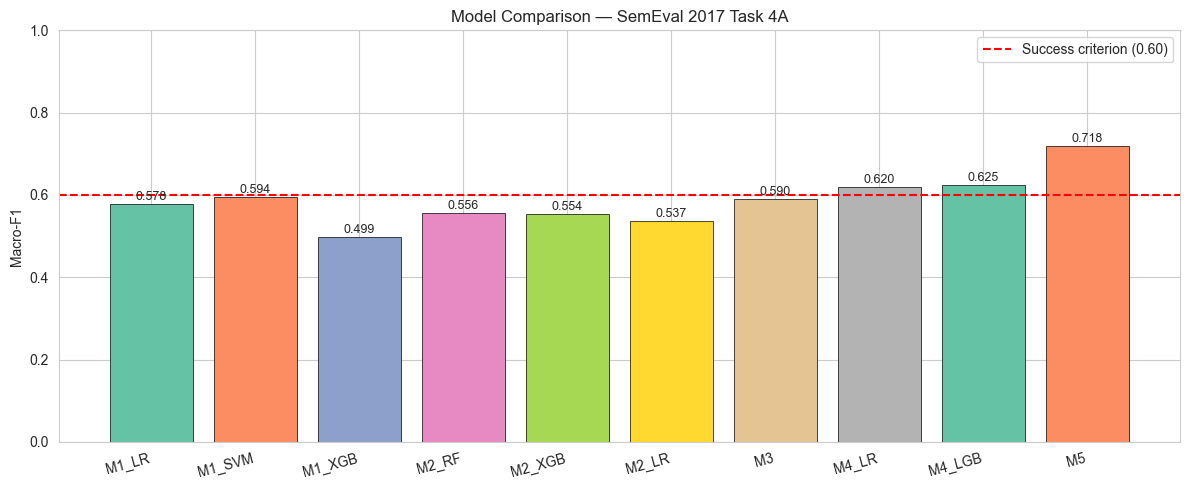

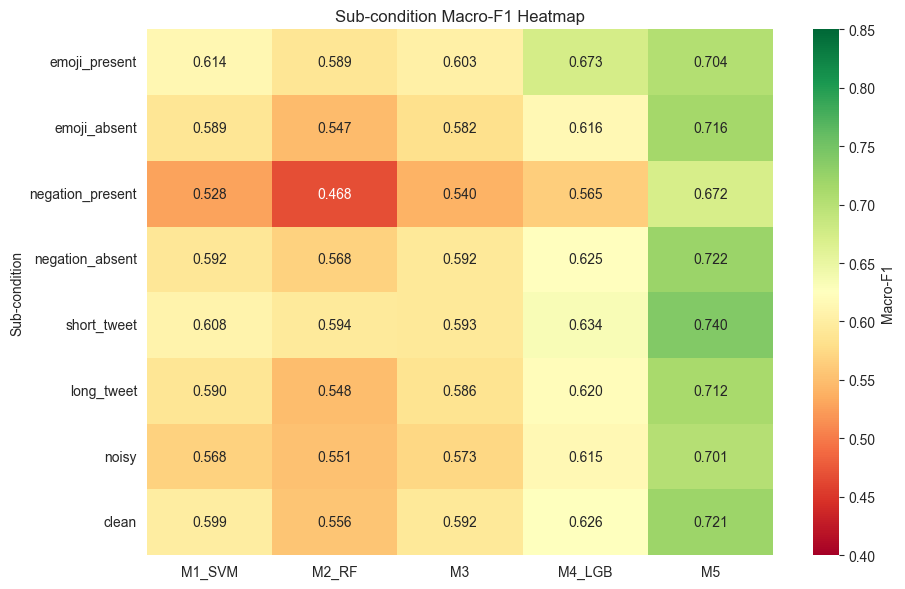

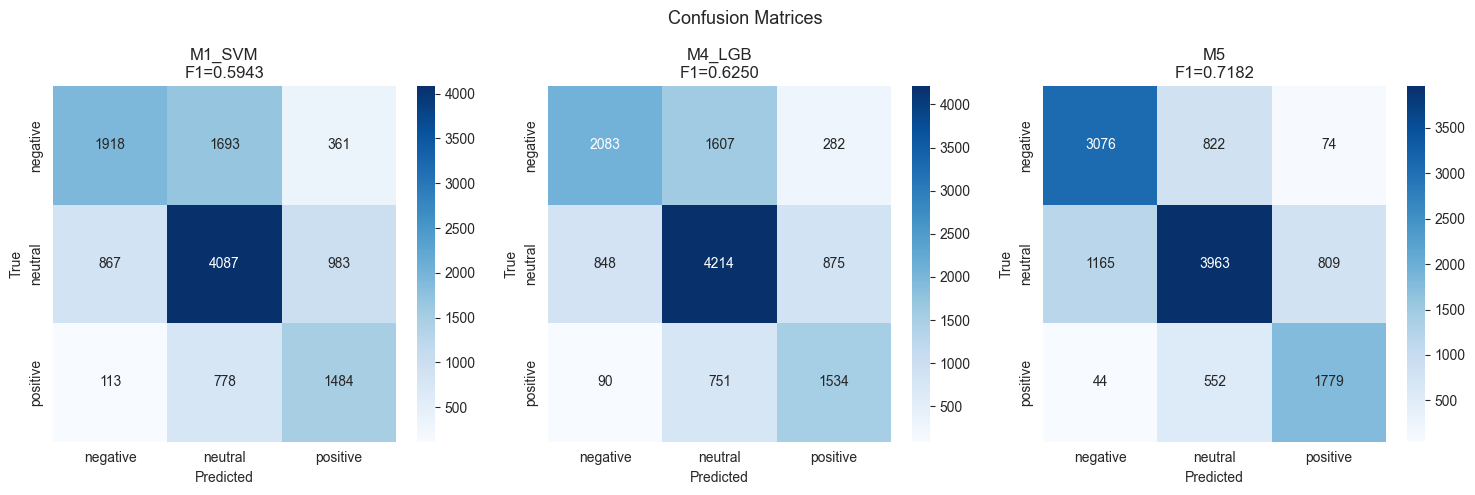

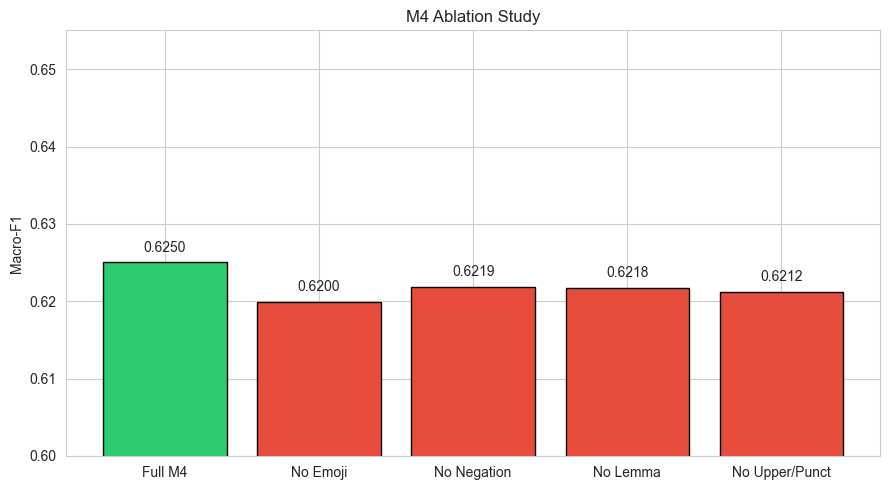

✅ Figures saved to /Users/luissoetherio/Documents/NLP_FInal Project/results/figures


In [37]:
sns.set_style('whitegrid')
COLORS  = sns.color_palette('Set2', 10)
FIG_DIR = os.path.join(RESULTS_DIR, 'figures')
os.makedirs(FIG_DIR, exist_ok=True)

# 1. Macro-F1 bar chart
fig, ax = plt.subplots(figsize=(12, 5))
models_p = [r['Model'] for _,r in df_results.iterrows()]
f1_vals  = [float(r['Macro-F1']) for _,r in df_results.iterrows()]
bars = ax.bar(models_p, f1_vals, color=COLORS[:len(models_p)], edgecolor='k', linewidth=0.5)
ax.axhline(0.60, color='red', linestyle='--', label='Success criterion (0.60)')
for bar, val in zip(bars, f1_vals):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9)
ax.set_ylim(0, 1.0); ax.set_ylabel('Macro-F1')
ax.set_title('Model Comparison — SemEval 2017 Task 4A')
ax.legend(); plt.xticks(rotation=15, ha='right'); plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'macro_f1_comparison.png'), dpi=150); plt.show()

# 2. Sub-condition heatmap
heat = df_subsets.set_index('Sub-condition').astype(float)
fig, ax = plt.subplots(figsize=(len(heat.columns)*1.5+2, 6))
sns.heatmap(heat, annot=True, fmt='.3f', cmap='RdYlGn',
            vmin=0.4, vmax=0.85, ax=ax, cbar_kws={'label':'Macro-F1'})
ax.set_title('Sub-condition Macro-F1 Heatmap'); plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'subcondition_heatmap.png'), dpi=150); plt.show()

# 3. Confusion matrices
key_preds = [(best_m1_name, ALL_RESULTS[best_m1_name]['preds']),
             (best_m4_name, ALL_RESULTS[best_m4_name]['preds']),
             ('M5',         ALL_RESULTS['M5']['preds'])]
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (mname, preds) in zip(axes, key_preds):
    sns.heatmap(confusion_matrix(y_test, preds), annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES)
    ax.set_title(f'{mname}\nF1={ALL_RESULTS[mname]["macro_f1"]:.4f}')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.suptitle('Confusion Matrices', fontsize=13); plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'confusion_matrices.png'), dpi=150); plt.show()

# 4. Ablation bar
full_m4_f1 = ALL_RESULTS[best_m4_name]['macro_f1']
abl_f1s  = [full_m4_f1] + [ALL_RESULTS[a]['macro_f1'] for a in ablation_names if a in ALL_RESULTS]
abl_lbls = ['Full M4','No Emoji','No Negation','No Lemma','No Upper/Punct']
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(abl_lbls[:len(abl_f1s)], abl_f1s,
              color=['#2ecc71']+['#e74c3c']*(len(abl_f1s)-1), edgecolor='k')
for bar, val in zip(bars, abl_f1s):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.001,
            f'{val:.4f}', ha='center', va='bottom', fontsize=10)
ax.set_ylim(min(abl_f1s)-0.02, max(abl_f1s)+0.03)
ax.set_ylabel('Macro-F1'); ax.set_title('M4 Ablation Study'); plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'ablation_study.png'), dpi=150); plt.show()
print(f'✅ Figures saved to {FIG_DIR}')

---
# ✅ CELL 23 — Final Checklist & Reproducibility Report

In [39]:
print('='*70)
print('REPRODUCIBILITY & SUCCESS CRITERIA REPORT')
print('='*70)
print(f'\n🔒 Random seed: SEED={SEED}')
print(f'🔒 BERTweet label mapping: verified programmatically via id2label')
print(f'🔒 M4 OOF protocol: 5-fold stratified CV, no leakage')
print(f'🔒 McNemar Bonferroni-corrected threshold: {alpha/n_tests:.5f}')

best_single_f1 = max(ALL_RESULTS[k]['macro_f1'] for k in list(M1_BEST)+list(M2_BEST))
m3_f1  = ALL_RESULTS['M3']['macro_f1']
m4_f1  = ALL_RESULTS[best_m4_name]['macro_f1']
m5_f1  = ALL_RESULTS.get('M5', {}).get('macro_f1', 0)
m4_sub = ALL_RESULTS[best_m4_name].get('subset_f1', {})
m3_sub = ALL_RESULTS['M3'].get('subset_f1', {})
m4_wins = sum(1 for c in set(m4_sub)&set(m3_sub) if m4_sub[c] > m3_sub[c])

sc1 = best_single_f1 >= 0.60
sc2 = m3_f1 > ALL_RESULTS[best_m1_name]['macro_f1'] and m3_f1 > ALL_RESULTS[best_m2_name]['macro_f1']
sc3 = m4_wins >= 2
sc4 = m5_f1 >= m4_f1

print('\n── Success Criteria ──')
print(f'  SC1 Best single ≥0.60   : {best_single_f1:.4f}  {"✅" if sc1 else "❌"}')
print(f'  SC2 M3 > M1 and M2      : {"✅" if sc2 else "❌"}  (M3={m3_f1:.4f})')
print(f'  SC3 M4 wins ≥2 subsets  : {m4_wins} wins  {"✅" if sc3 else "❌"}')
print(f'  SC4 M5 highest F1       : {m5_f1:.4f}  {"✅" if sc4 else "❌"}')
print(f'\n✅ Experiment complete. All outputs saved locally.')

REPRODUCIBILITY & SUCCESS CRITERIA REPORT

🔒 Random seed: SEED=42
🔒 BERTweet label mapping: verified programmatically via id2label
🔒 M4 OOF protocol: 5-fold stratified CV, no leakage
🔒 McNemar Bonferroni-corrected threshold: 0.00714

── Success Criteria ──
  SC1 Best single ≥0.60   : 0.5943  ❌
  SC2 M3 > M1 and M2      : ❌  (M3=0.5898)
  SC3 M4 wins ≥2 subsets  : 8 wins  ✅
  SC4 M5 highest F1       : 0.7182  ✅

✅ Experiment complete. All outputs saved locally.
